### Astrostatistics lecture 15

In [63]:
import urllib.request
import pandas as pd
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm
from scipy import stats
from sklearn.cluster import KMeans
from sklearn import preprocessing
from sklearn.cluster import MeanShift
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler


urllib.request.urlretrieve("https://raw.githubusercontent.com/nshaud/ml_for_astro/main/stars.csv", "stars.csv")
df_stars = pd.read_csv("stars.csv")

In [10]:
df_stars        #our data set

,Temperature (K),Luminosity(L/Lo),Radius(R/Ro),Absolute magnitude(Mv),Star type,Star color,Spectral Class
0,3068,0.002400,0.1700,16.12,Brown Dwarf,Red,M
1,3042,0.000500,0.1542,16.60,Brown Dwarf,Red,M
2,2600,0.000300,0.1020,18.70,Brown Dwarf,Red,M
3,2800,0.000200,0.1600,16.65,Brown Dwarf,Red,M
4,1939,0.000138,0.1030,20.06,Brown Dwarf,Red,M
...,...,...,...,...,...,...,...
235,38940,374830.000000,1356.0000,-9.93,Hypergiant,Blue,O
236,30839,834042.000000,1194.0000,-10.63,Hypergiant,Blue,O
237,8829,537493.000000,1423.0000,-10.73,Hypergiant,White,A
238,9235,404940.000000,1112.0000,-11.23,Hypergiant,White,A


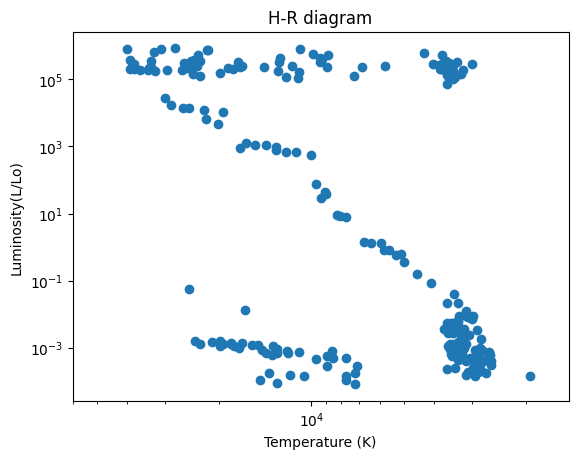

In [35]:
#need to extract the features from the data set, so we convert them in arrays

temperature = np.array(df_stars["Temperature (K)"])
luminosity = np.array(df_stars["Luminosity(L/Lo)"])
radius = np.array(df_stars["Radius(R/Ro)"])
absolute_magnitude = np.array(df_stars["Absolute magnitude(Mv)"])
classification = np.array(df_stars["Star type"])

plt.scatter(temperature, luminosity)
plt.title('H-R diagram')
plt.xscale('log')
plt.yscale('log')
plt.xlim(max(temperature)*1.5, min(temperature)*0.75)
plt.xlabel("Temperature (K)")
plt.ylabel("Luminosity(L/Lo)")
plt.show()

In [ ]:
data = np.array([temperature, luminosity, radius, absolute_magnitude])
data = StandardScaler().fit_transform(data.T).T

pca = PCA(n_components=2) # 2 components
pca.fit(data)

evals = pca.explained_variance_ratio_ 
print(evals)


[[-0.7793821  -0.78210961 -0.82847728 -0.80749644 -0.89781898 -0.80330027
  -0.82459583 -0.82847728 -0.82323207 -0.81798686 -0.72357305 -0.77298294
  -0.77245842 -0.72063573 -0.82323207 -0.75084815 -0.80760134 -0.71392186
  -0.76637397 -0.74025282  1.52137764 -0.2892695  -0.34381971 -0.20954228
   0.62969162  0.26147775 -0.20219898 -0.29346567  0.13559266 -0.34277066
   2.99003697  2.04589883  0.50128883 -0.0836572  -0.49278372 -0.25653938
  -0.39239037 -0.43193926 -0.47851675 -0.51512833 -0.69986469 -0.74822554
  -0.75819144 -0.76553474 -0.78567635 -0.72357305 -0.72619565 -0.72630056
  -0.72095044  2.43928972 -0.73511251 -0.70783741 -0.69902545 -0.70794231
  -0.71832783 -0.73930868 -0.71727879 -0.73930868 -0.7076276  -0.73039182
  -0.75074324 -0.74119696 -0.78829896 -0.80382479 -0.79333436 -0.75556884
  -0.79228532 -0.80571306 -0.81022395 -0.80004823 -0.75032363 -0.72283872
  -0.7546247  -0.77077995 -0.72881826 -0.76763283 -0.79805505 -0.75063834
  -0.82627429 -0.76994072 -0.35640821 

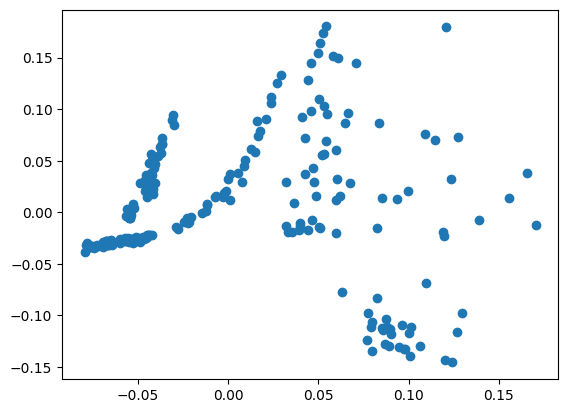

In [66]:
plt.scatter(pca.components_[0], pca.components_[1])